# LELA60342 Week 6 - Evaluation: ROC Analysis

In [1]:
import numpy as np
## Create simulated data
#np.random.seed(10)
w1_center = (2, 3)
w2_center = (3, 2)
batch_size=1000

x = np.zeros((batch_size, 2))
y = np.zeros(batch_size)
for i in range(batch_size):
    if np.random.random() > 0.5:
        x[i] = np.random.normal(loc=w1_center,scale=10)
    else:
        x[i] = np.random.normal(loc=w2_center,scale=10)
        y[i] = 1




In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)
logisticRegr = LogisticRegression()
logisticRegr.fit(x_train, y_train)

LogisticRegression()

In [3]:
from sklearn.metrics import precision_recall_fscore_support
precision_recall_fscore_support(y_test,logisticRegr.predict(x_test),average="macro")[2]

0.5066495066495067

In [5]:
from sklearn.metrics import roc_curve, auc

In [10]:
logisticRegr.predict_proba(x_test).T[1]

array([0.56471127, 0.5385601 , 0.52081474, 0.50672184, 0.55380324,
       0.48814495, 0.4895768 , 0.52795591, 0.4668085 , 0.51262387,
       0.46687443, 0.48524684, 0.49714438, 0.52658863, 0.55061377,
       0.49846096, 0.55127828, 0.5309127 , 0.5260453 , 0.48411287,
       0.57046445, 0.55412139, 0.54560453, 0.53026927, 0.55020261,
       0.51786109, 0.5439883 , 0.50356162, 0.50710464, 0.50768656,
       0.53326456, 0.43566302, 0.58422656, 0.4727981 , 0.4842153 ,
       0.49995603, 0.56488434, 0.51599411, 0.55223019, 0.48731352,
       0.54053344, 0.39857454, 0.51804363, 0.57950515, 0.57036143,
       0.47842434, 0.48718617, 0.58236996, 0.5050306 , 0.52547092,
       0.4927923 , 0.46879357, 0.53425813, 0.4662781 , 0.51168059,
       0.54582319, 0.48069362, 0.53758049, 0.51309165, 0.5178772 ,
       0.5503093 , 0.55139456, 0.46091955, 0.51086144, 0.49280564,
       0.46803725, 0.50335586, 0.49866194, 0.56693555, 0.56479858,
       0.54583357, 0.56915905, 0.52883205, 0.54788189, 0.49950

In [19]:
fpr, tpr, thresholds = roc_curve(y_test,logisticRegr.predict_proba(x_test).T[1])

In [23]:
thresholds

array([       inf, 0.60878766, 0.60061876, 0.5971034 , 0.59077399,
       0.58422656, 0.58236996, 0.57927307, 0.57129557, 0.56972961,
       0.56915905, 0.56780071, 0.56491691, 0.56469478, 0.56402269,
       0.5635149 , 0.55822798, 0.55613646, 0.55223019, 0.55139456,
       0.55076205, 0.55020261, 0.54809793, 0.54788189, 0.54675595,
       0.54587134, 0.54583357, 0.54582319, 0.54392499, 0.54349776,
       0.53758049, 0.53715868, 0.5365198 , 0.53593563, 0.53425813,
       0.53424805, 0.53391531, 0.53267674, 0.5317073 , 0.53166059,
       0.5309127 , 0.53026927, 0.52992655, 0.52883205, 0.52795591,
       0.52658863, 0.52547092, 0.52421836, 0.52153802, 0.51959462,
       0.51665103, 0.51627349, 0.51608994, 0.51526575, 0.5144501 ,
       0.5141064 , 0.51400277, 0.51309165, 0.51264413, 0.51168059,
       0.51086144, 0.51077441, 0.51017629, 0.50768656, 0.5074132 ,
       0.50680013, 0.50658059, 0.50652736, 0.50558113, 0.50382907,
       0.50335586, 0.50289857, 0.50228813, 0.49995603, 0.49829

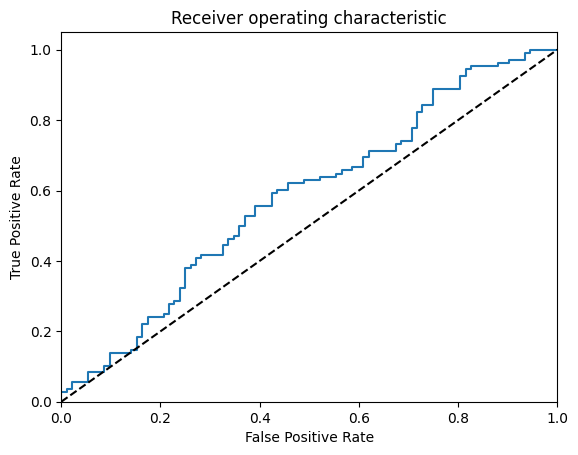

In [22]:
import matplotlib.pyplot as plt


plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.show()

# Area under the curve